In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 3** - Drug Discovery Project

- **Objective** - drug discovery project, testing combinations of three compounds to create a new medicine.
- Each experiment is stored in `initial_inputs.npy` as a 3D array, where each row lists the amounts of the three compounds used.
  - After each experiment, you record the number of adverse reactions, stored in `initial_outputs.npy` as a 1D array.

- **Final Goal** - minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

- **Input:** 3D array (15, 3)
- **Output:** 3D array (15,)
- **Optimization Goal** - maximise


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_3\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_3\initial_outputs.npy')

### **Random Search**


- This is the fist simple method to get a query just to explore thorugh trial-and-error method to just get a guage of the space.


In [3]:
next_query = np.random.uniform(size = 3)
print(next_query)

[0.41585476 0.7926453  0.09778163]


### **Bayesian Optimisation** - More strategic approach


- For this particular problem I am using the Matern kerenl as in comparison the RBF kerel is a bit too smooth whereas in this paricular looking at the use case we need to use a Matern.
  - This should help us capture the sensitive chemical interactions while still remaining differentiable.


In [7]:
kernel = Matern(length_scale=1.0, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=0.01,
    normalize_y=True,
    random_state=42
)

model.fit(X, Y)

GaussianProcessRegressor(alpha=0.01, kernel=Matern(length_scale=1, nu=2.5),
                         n_restarts_optimizer=10, normalize_y=True,
                         random_state=42)

### **Acquisition Function**

- I want to use expected improvements (EI) as it is superior for higher dimensions.
  - Particularly reason for me to choose this is that it looks for the "Expected" value of the improvement.
    - This helps navigate the larger 3D search space more efficiently.


In [8]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    
    return ei.ravel()

### **Search and explore the 3D space**

- I have choosen to generate 50,000 points because the 3D space is a lot less populated as compared to the 2D space.


In [9]:
y_max = np.max(Y)

x_grid = np.random.uniform(0, 1, size=(50000, 3))

ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"\nNext query point suggested by EI acquisition function: [{next_query[0]:.6f}, {next_query[1]:.6f}, {next_query[2]:.6f}]")


Next query point suggested by EI acquisition function: [0.338257, 0.307971, 0.472399]


### **Visualisation of sequential outputs for Function 3**


The visulisation I have gone for here is to map out the outputs per week.


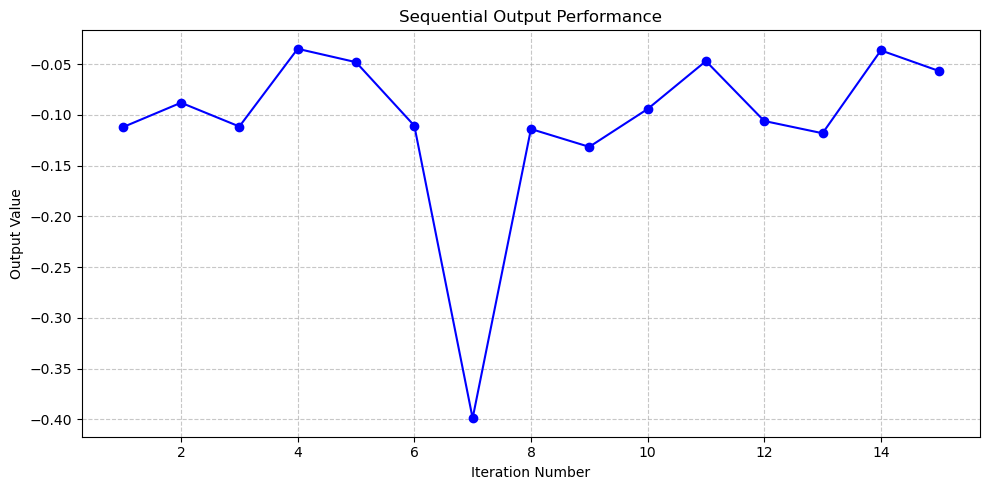

In [10]:
iterations = np.arange(1, len(Y) + 1)

# Plot the output values in order
plt.figure(figsize=(10, 5))
plt.plot(iterations, Y, marker='o', linestyle='-', color='b')

# Simple titles and axis labels
plt.title('Sequential Output Performance')
plt.xlabel('Iteration Number')
plt.ylabel('Output Value')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Reasons for having a different input values for week 1 than what is shown here**

**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.021588-0.984211-0.542109]

- I will be using this thinking process and methodology moving forward into week 2.
